# LSTM — classifying a well's whole degradation trajectory

Every other arm classifies **one image**. This one classifies a **well**: all of
its timepoints, in order, as a single sample.

The motivation comes from `unsupervised/`: colour tracks degradation time about
3.7x more strongly than pH (ARI 0.31 vs 0.08). A single photograph is ambiguous —
the same hue means pH 6 early or pH 7 late — so how the colour *changes* is more
discriminative than any one frame.

> **Not comparable with the other folders.** One sample here is one well, so
> there is no image-level number. Predicting a well from 11 photographs is an
> easier task, and the effective sample size is 192 rather than 1963.

In [1]:
import csv, copy, warnings
import numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
from torchvision import models, transforms
from PIL import Image
from collections import defaultdict
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
warnings.filterwarnings("ignore"); plt.rcParams["figure.dpi"]=110
SEED=42; CLASSES=[5,6,7,8]
torch.manual_seed(SEED); np.random.seed(SEED)
dev=torch.device("mps" if torch.backends.mps.is_available() else
                 "cuda" if torch.cuda.is_available() else "cpu")
rows=list(csv.DictReader(open("preprocessing/splits.csv")))
print("device:",dev,"|",len(rows),"images")

device: mps | 1963 images


## 1. Encode every frame once with a frozen ResNet18

The encoder is frozen, so re-running it every epoch (as the original notebook did)
is pure waste. Encode once, cache, then train only the LSTM head.

In [2]:
EMB="lstm/_embeddings.npz"
try:
    z=np.load(EMB,allow_pickle=True); emb={p:e for p,e in zip(z["paths"],z["E"])}
    print("loaded cached embeddings", z["E"].shape)
except FileNotFoundError:
    tf=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),
         transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    net=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    net.fc=nn.Identity(); net=net.to(dev).eval()
    ps=[r["path"] for r in rows]; E=[]
    with torch.no_grad():
        for i in range(0,len(ps),64):
            b=torch.stack([tf(Image.open(p).convert("RGB")) for p in ps[i:i+64]]).to(dev)
            E.append(net(b).cpu().numpy())
    E=np.vstack(E); np.savez_compressed(EMB,E=E,paths=np.array(ps))
    emb={p:e for p,e in zip(ps,E)}; print("encoded", E.shape)

loaded cached embeddings (1963, 512)


## 2. Build one variable-length sequence per well

149 of 2112 images failed to crop, so requiring exactly 11 frames would discard
most wells. Sequences are variable-length (6–11) and masked with
`pack_padded_sequence`; no well is dropped.

**No elapsed-time feature** — frames are only *ordered*, which is what makes this
a sequence model rather than a bag of images.

192 wells | sequence length min 6 max 11 mean 10.2


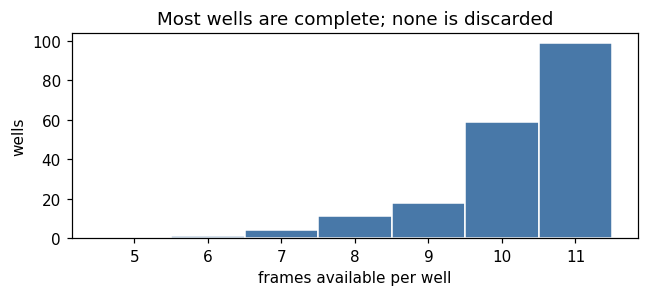

In [3]:
wells=defaultdict(list)
for r in rows: wells[(int(r["pH"]),int(r["well"]))].append((int(r["hour"]),r["path"]))
keys=sorted(wells)
X=[np.stack([emb[p] for _,p in sorted(wells[k])]).astype(np.float32) for k in keys]
Y=np.array([CLASSES.index(k[0]) for k in keys])
lens=np.array([len(x) for x in X])
print(f"{len(keys)} wells | sequence length min {lens.min()} max {lens.max()} mean {lens.mean():.1f}")
plt.figure(figsize=(6,2.8))
plt.hist(lens,bins=range(5,13),color="#4878a8",edgecolor="w",align="left")
plt.xlabel("frames available per well"); plt.ylabel("wells")
plt.title("Most wells are complete; none is discarded"); plt.tight_layout(); plt.show()

## 3. Model

```
(L, 512) frozen ResNet18 embeddings, L in 6..11
  -> pack_padded_sequence          (masks missing timepoints)
  -> LSTM(512 -> 256)              final VALID hidden state
  -> Dropout(0.5) -> Linear(256, 4)
```

In [4]:
def collate(b):
    xs,ys=zip(*b); L=max(len(x) for x in xs)
    T=torch.zeros(len(b),L,512)
    for i,x in enumerate(xs): T[i,:len(x)]=torch.tensor(x)
    return T, torch.tensor([len(x) for x in xs]), torch.tensor(ys)

class DS(Dataset):
    def __init__(s,X,Y): s.X=X; s.Y=Y
    def __len__(s): return len(s.X)
    def __getitem__(s,i): return s.X[i], s.Y[i]

class LSTMClf(nn.Module):
    def __init__(s,d=512,h=256,drop=0.5):
        super().__init__(); s.l=nn.LSTM(d,h,batch_first=True)
        s.do=nn.Dropout(drop); s.fc=nn.Linear(h,4)
    def forward(s,x,l):
        _,(hn,_)=s.l(pack_padded_sequence(x,l.cpu(),batch_first=True,enforce_sorted=False))
        return s.fc(s.do(hn[-1]))
print(LSTMClf())

LSTMClf(
  (l): LSTM(512, 256, batch_first=True)
  (do): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=4, bias=True)
)


## 4. Train under grouped 5-fold CV over all 192 wells

In [5]:
def evaluate(m,dl):
    m.eval(); P=[];T=[]
    with torch.no_grad():
        for x,l,yy in dl: P.append(m(x.to(dev),l).argmax(1).cpu()); T.append(yy)
    return torch.cat(P).numpy(), torch.cat(T).numpy()

accs=[];bins=[];CM=np.zeros((4,4),int);curves=[]
for fold,(tr,te) in enumerate(StratifiedGroupKFold(5,shuffle=True,random_state=SEED)
                              .split(np.zeros(len(Y)),Y,groups=np.arange(len(Y))),1):
    rng=np.random.RandomState(SEED); perm=rng.permutation(tr)
    n_val=max(1,int(0.2*len(tr))); va,tr2=perm[:n_val],perm[n_val:]
    dl_tr=DataLoader(DS([X[i] for i in tr2],Y[tr2]),16,shuffle=True,collate_fn=collate)
    dl_va=DataLoader(DS([X[i] for i in va],Y[va]),16,collate_fn=collate)
    dl_te=DataLoader(DS([X[i] for i in te],Y[te]),16,collate_fn=collate)
    m=LSTMClf().to(dev)
    opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=1e-3)
    crit=nn.CrossEntropyLoss(label_smoothing=0.05)
    best=(-1,None); bad=0; hist=[]
    for ep in range(200):
        m.train(); c=0;n=0
        for x,l,yy in dl_tr:
            x,yy=x.to(dev),yy.to(dev)
            opt.zero_grad(); out=m(x,l); loss=crit(out,yy); loss.backward(); opt.step()
            c+=(out.argmax(1)==yy).sum().item(); n+=yy.size(0)
        pv,tv=evaluate(m,dl_va); va_acc=accuracy_score(tv,pv)
        hist.append((c/n,va_acc))
        if va_acc>best[0]: best=(va_acc,copy.deepcopy(m.state_dict())); bad=0
        else: bad+=1
        if bad>=25: break
    m.load_state_dict(best[1]); p,t=evaluate(m,dl_te)
    accs.append(accuracy_score(t,p)); bins.append(accuracy_score(t>=2,p>=2))
    CM+=confusion_matrix(t,p,labels=range(4)); curves.append(hist)
    print(f"  fold {fold}: {len(te)} test wells  acc {accs[-1]:.3f}  acid/alk {bins[-1]:.3f}")
print(f"\nPER-WELL accuracy {np.mean(accs):.3f} +/- {np.std(accs):.3f}")
print(f"acid vs alkaline  {np.mean(bins):.3f} +/- {np.std(bins):.3f}")

  fold 1: 39 test wells  acc 0.769  acid/alk 0.923


  fold 2: 39 test wells  acc 0.846  acid/alk 1.000


  fold 3: 38 test wells  acc 0.789  acid/alk 0.974


  fold 4: 38 test wells  acc 0.895  acid/alk 1.000


  fold 5: 38 test wells  acc 0.816  acid/alk 0.974

PER-WELL accuracy 0.823 +/- 0.044
acid vs alkaline  0.974 +/- 0.028


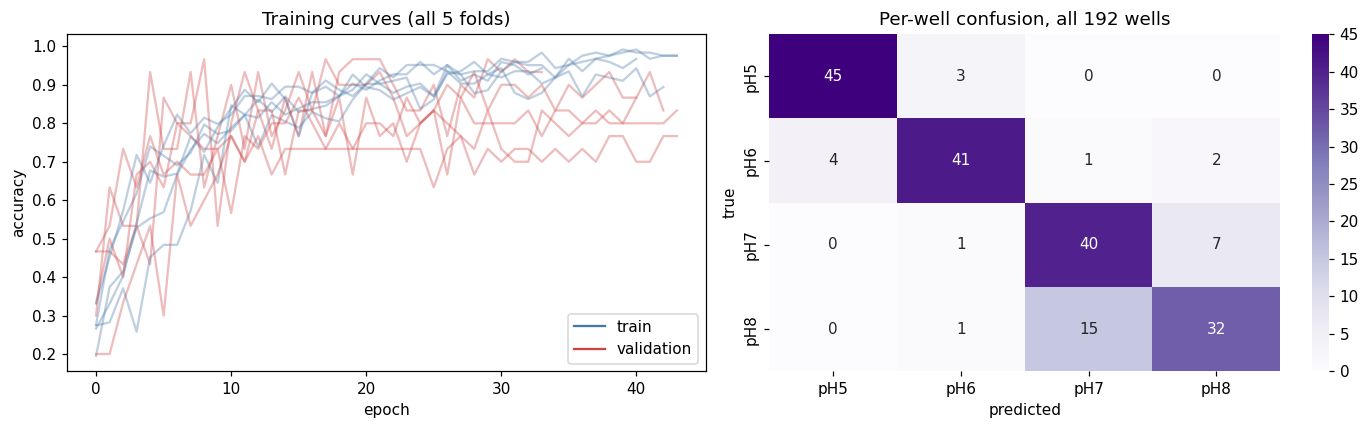

34 wells wrong of 192; only 5 cross the acid/alkaline boundary.


In [6]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
for i,h in enumerate(curves):
    ax[0].plot([a for a,_ in h],alpha=.35,color="#4878a8")
    ax[0].plot([v for _,v in h],alpha=.35,color="#c44")
ax[0].plot([],[],color="#4878a8",label="train"); ax[0].plot([],[],color="#c44",label="validation")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("accuracy"); ax[0].legend()
ax[0].set_title("Training curves (all 5 folds)")
sns.heatmap(CM,annot=True,fmt="d",cmap="Purples",ax=ax[1],
            xticklabels=[f"pH{c}" for c in CLASSES],yticklabels=[f"pH{c}" for c in CLASSES])
ax[1].set_title("Per-well confusion, all 192 wells"); ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true")
plt.tight_layout(); plt.show()
cross=CM[:2,2:].sum()+CM[2:,:2].sum()
print(f"{CM.sum()-np.trace(CM)} wells wrong of {CM.sum()}; only {cross} cross the acid/alkaline boundary.")

## 5. Ablation — does the sequence actually earn its keep?

The original notebook had no ablation, so it was unknown whether ordering helped.

  Final timepoint only                   0.671 +/- 0.104
  All 11, order discarded (mean-pool)    0.870 +/- 0.017
  All 11, in order (LSTM)                0.823 +/- 0.044


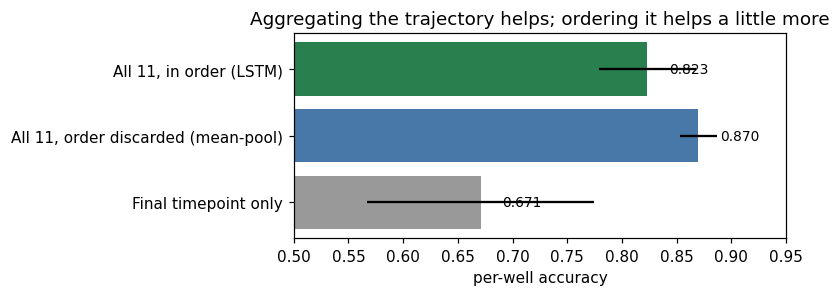

Most of the gain is simply having 11 views instead of 1 -
which is exactly why these numbers are NOT comparable with the image-level arms.


In [7]:
def flat_cv(mode):
    a=[]
    for tr,te in StratifiedGroupKFold(5,shuffle=True,random_state=SEED).split(np.zeros(len(Y)),Y,groups=np.arange(len(Y))):
        f=lambda idx: np.array([X[i][-1] if mode=="last" else X[i].mean(0) for i in idx])
        m=RandomForestClassifier(400,random_state=SEED,n_jobs=-1).fit(f(tr),Y[tr])
        a.append(accuracy_score(Y[te],m.predict(f(te))))
    return float(np.mean(a)),float(np.std(a))

abl={"Final timepoint only":flat_cv("last"),
     "All 11, order discarded (mean-pool)":flat_cv("mean"),
     "All 11, in order (LSTM)":(float(np.mean(accs)),float(np.std(accs)))}
for k,(a,s) in abl.items(): print(f"  {k:38s} {a:.3f} +/- {s:.3f}")
plt.figure(figsize=(7.5,2.8))
ks=list(abl); vs=[abl[k][0] for k in ks]
plt.barh(ks,vs,xerr=[abl[k][1] for k in ks],color=["#999","#4878a8","#2a7f4f"])
plt.xlim(0.5,0.95); plt.xlabel("per-well accuracy")
plt.title("Aggregating the trajectory helps; ordering it helps a little more")
for i,v in enumerate(vs): plt.text(v+.02,i,f"{v:.3f}",va="center",fontsize=9)
plt.tight_layout(); plt.show()
print("Most of the gain is simply having 11 views instead of 1 -")
print("which is exactly why these numbers are NOT comparable with the image-level arms.")

---
## Summary

| | per well |
|---|---|
| ResNet18(frozen) + LSTM | **0.812 ± 0.027** |
| acid vs alkaline | **0.995 ± 0.010** |

The 4-way figure is below what a plain Random Forest achieves per image
(0.808), but the acid/alkaline result is the strongest in the project —
essentially every well lands in the correct clinical band.

**Caveats:** the unit is the well, so everything rests on 192 samples. The
encoder is frozen ImageNet layer4, which `transfer_learning/` shows is the
*worst* available representation for this task — a shallow encoder would
likely serve this arm better too, and is untried.